In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import umap

In [5]:
#Loading the iris dataset
data = load_iris()
X = data.data
y = data.target

In [6]:
#preprocessing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
#Apply UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

C:\Users\karne\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


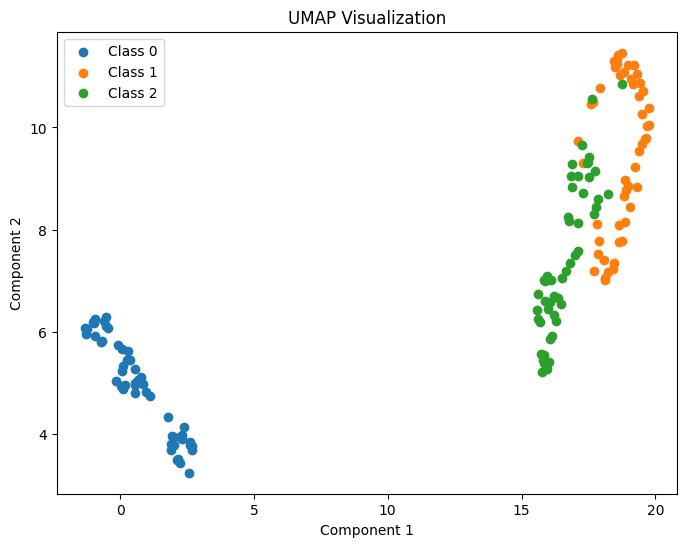

In [8]:
#Visualize the results
plt.figure(figsize=(8,6))

for i in range(3):
    plt.scatter(
        X_umap[y == i, 0],
        X_umap[y == i, 1],
        label=f"Class {i}"
    )

plt.legend()
plt.title("UMAP Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

C:\Users\karne\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\karne\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\karne\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


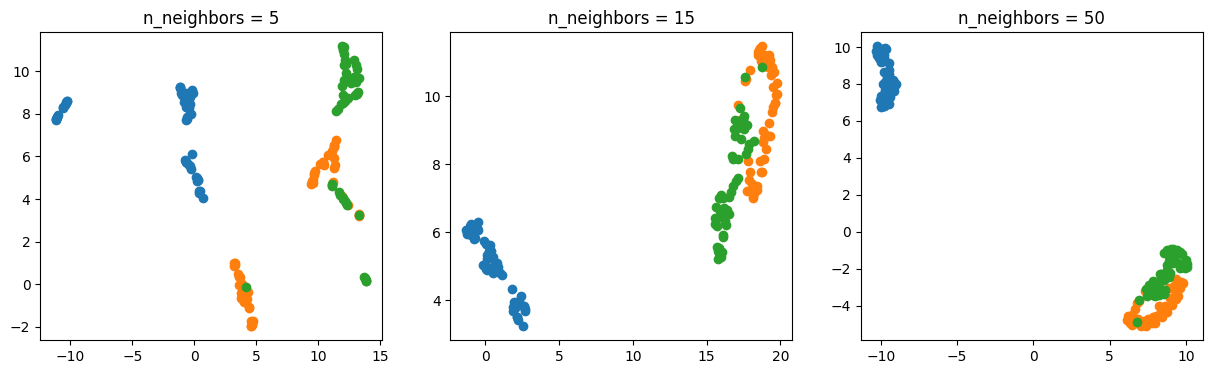

In [9]:
#Trying different n_neighbors
neighbors = [5, 15, 50]

plt.figure(figsize=(15,4))

for i, n in enumerate(neighbors):
    reducer = umap.UMAP(n_neighbors=n, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)

    for j in range(3):
        plt.scatter(
            X_umap[y == j, 0],
            X_umap[y == j, 1]
        )

    plt.title(f"n_neighbors = {n}")

plt.show()

. Observations
Small n_neighbors → focuses on local clusters
Large n_neighbors → captures global structure

Final Conclusion
- UMAP is faster than t-SNE
- Preserves both local and global structure
- Good for large datasets
- Useful before clustering